In [ ]:
!pip install ucimlrepo
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn
!pip install xgboost
!pip install tqdm


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
ERROR: Ignored the following yanked versions: 0.1.6, 0.1.7, 0.1.8, 0.1.9, 0.2.0, 0.2.1, 0.2.2, 0.2.2.post2, 0.2.2.post3
ERROR: Could not find a version that satisfies the requirement torchvision (from versions: none)

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
ERROR:

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, QuantileTransformer
import xgboost as xgb


In [77]:
def write_variable_descriptions(variables: pd.DataFrame, output_path: str) -> None:
    lines = []

    if "name" in variables.columns and "description" in variables.columns:
        for _, row in variables.iterrows():
            name = row["name"]
            description = row["description"]

            if pd.isna(description):
                description = "No description available."

            lines.append(f"{name}:")
            lines.append(str(description).strip())
            lines.append("")
    else:
        # Fallback: store the full table if the expected columns are unavailable.
        lines.append(variables.to_string(index=False))

    Path(output_path).write_text("\n".join(lines).rstrip() + "\n", encoding="utf-8")


# fetch dataset
bank_marketing = fetch_ucirepo(id=222)

# data (as pandas dataframes)
X = bank_marketing.data.features
y = bank_marketing.data.targets

# variable information 
print(bank_marketing.variables) 

# variable information
write_variable_descriptions(bank_marketing.variables, "variable_information.txt")
print("Saved variable descriptions to variable_information.txt")

# store data in csv file, put X,y together
df = pd.concat([X, y], axis=1)
df.to_csv('bank_marketing.csv', index=False)

           name     role         type      demographic  \
0           age  Feature      Integer              Age   
1           job  Feature  Categorical       Occupation   
2       marital  Feature  Categorical   Marital Status   
3     education  Feature  Categorical  Education Level   
4       default  Feature       Binary              NaN   
5       balance  Feature      Integer              NaN   
6       housing  Feature       Binary              NaN   
7          loan  Feature       Binary              NaN   
8       contact  Feature  Categorical              NaN   
9   day_of_week  Feature         Date              NaN   
10        month  Feature         Date              NaN   
11     duration  Feature      Integer              NaN   
12     campaign  Feature      Integer              NaN   
13        pdays  Feature      Integer              NaN   
14     previous  Feature      Integer              NaN   
15     poutcome  Feature  Categorical              NaN   
16            

In [78]:
# Data Preprocessing Step 1: handle missing and inconsistent values

# Expected Values for each categorical column
expected_job = {
    'admin.', 'blue-collar', 'entrepreneur', 'housemaid', 'management',
    'retired', 'self-employed', 'services', 'student', 'technician',
    'unemployed', 'unknown'
}

expected_martial = {
    'single', 'married', 'divorced', 'unknown'
}

expected_education = {
    'primary', 'secondary', 'tertiary', 'unknown'
}

expected_contact = {
    'cellular', 'telephone', 'unknown'
}

expected_poutcome = {
    'unknown', 'other', 'failure', 'success'
}

binary_columns = {
    'yes', 'no'
}

# 1. Age: check if there are any missing values or inconsistent(non integer or negative)
# check if there are any missing values
missing_age = df['age'].isnull().sum()
print(f"Number of missing age values: {missing_age}")

# check if there are any inconsistent values (negative or non integer)
inconsistent_age = df[~df['age'].isin(range(0, 100))]
print(f"Number of inconsistent age values: {len(inconsistent_age)}")

# 2. Job: check if there are any missing values    
# or inconsistent(null values or unexpected job)
missing_job = df['job'].isnull().sum()
print(f"Number of missing job values: {missing_job}")

# check how many non-null values are expected
expected_job = df['job'].isin(expected_job).sum()
print(f"Number of expected job values: {expected_job}")

# replace the null job column with 'unknown' tag
df['job'] = df['job'].fillna('unknown')

# 3. Martial: check if there are any missing values or 
# inconsistent(non string or unexpected martial)

# check how many martial column is missing
missing_martial = df['marital'].isnull().sum()
print(f"Number of missing martial values: {missing_martial}")

# check how many non-null values are expected
expected_martial = df['marital'].isin(expected_martial).sum()
print(f"Number of expected martial values: {expected_martial}")

# 4. Education: check if there are any missing values or 
# inconsistent(non string or unexpected education)

# check how many education column is missing
missing_education = df['education'].isnull().sum()
print(f"Number of missing education values: {missing_education}")

# check how many non-null values are expected
expected_education = df['education'].isin(expected_education).sum()
print(f"Number of expected education values: {expected_education}")

# replace the missing education column with 'unknown' tag
df['education'] = df['education'].fillna('unknown')

missing_education = df['education'].isnull().sum()
print(f"Number of missing education values: {missing_education}")

# 5. Default: check if there are any missing values or 
# inconsistent(non string or unexpected default)

# check how many default column is missing
missing_default = df['default'].isnull().sum()
print(f"Number of missing default values: {missing_default}")

# check how many non-null values are expected
expected_default = df['default'].isin(binary_columns).sum()
print(f"Number of expected default values: {expected_default}")

# 6. Balance: check if there are any missing values or 
# inconsistent(non integer or negative)

# check if there are any missing values
missing_balance = df['balance'].isnull().sum()
print(f"Number of missing balance values: {missing_balance}")

# check if there are any non-integer, it can be negative
non_integer_balance = df[~df['balance'].isin(range(-10000000, 10000000))]
print(f"Number of non-integer balance values: {len(non_integer_balance)}")

if len(non_integer_balance) > 0:
    print(f"There are {len(non_integer_balance)} non-integer balance values")
else:
    print("There are no non-integer balance values")

# 7. Housing: check if there are any missing values or 
# inconsistent(non string or unexpected housing)

# check how many housing column is missing
missing_housing = df['housing'].isnull().sum()
print(f"Number of missing housing values: {missing_housing}")

# check how many non-null values are expected
expected_housing = df['housing'].isin(binary_columns).sum()
print(f"Number of expected housing values: {expected_housing}")

# 8. Loan: check if there are any missing values or 
# inconsistent(non string or unexpected loan)

# check how many loan column is missing
missing_loan = df['loan'].isnull().sum()
print(f"Number of missing loan values: {missing_loan}")

# check how many non-null values are expected
expected_loan = df['loan'].isin(binary_columns).sum()
print(f"Number of expected loan values: {expected_loan}")

# 9. Contact: check if there are any missing values or 
# inconsistent(non string or unexpected contact)
# check how many contact column is missing (NaN or empty strings)
missing_contact = (df['contact'].isnull() | (df['contact'] == '')).sum()
print(f"Number of missing contact values: {missing_contact}")

# replace the missing contact column with 'unknown' tag
df['contact'] = df['contact'].replace('', 'unknown').fillna('unknown')

# verify the final count of 'expected' values including 'unknown'
expected_contact_count = df['contact'].isin(expected_contact).sum()
print(f"Number of expected contact values: {expected_contact_count}")

# verify no more missing values
missing_contact_after = (df['contact'].isnull() | (df['contact'] == '')).sum()
print(f"Number of missing contact values after filling: {missing_contact_after}")

# 10. Day_of_week & Month: check if there are any missing values or 
# inconsistent(non string or unexpected day_of_week or month)
# check missing values first
missing_day_of_week = df['day_of_week'].isnull().sum()
print(f"Number of missing day_of_week values: {missing_day_of_week}")

missing_month = df['month'].isnull().sum()
print(f"Number of missing month values: {missing_month}")

# then check if the date is valid since each month has a different number of days
# we can use the datetime module to check if the date is valid

expected_month = {
    'jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec'
}

expected_day_of_month = {
    'jan': 31, 'feb': 28, 'mar': 31, 'apr': 30, 'may': 31, 'jun': 30, 
    'jul': 31, 'aug': 31, 'sep': 30, 'oct': 31, 'nov': 30, 'dec': 31
}

# First check if the month is in expected_month
missing_month = df['month'].isin(expected_month).sum()
print(f"Number of missing month values: {missing_month}")

# Given the month of each row, check if the day of month is valid
# for each item, retrive month and set range (1, expected_day_of_month[month] + 1)
# check if the day of month is in the range
invalid_day_of_month = 0
for index, row in df.iterrows():
    month = row['month']
    day_of_month = row['day_of_week']
    if month in expected_day_of_month:
        if day_of_month > expected_day_of_month[month]:
            print(f"Invalid day of month for {month}: {day_of_month}")
            invalid_day_of_month += 1

print(f"Number of invalid day of month: {invalid_day_of_month}")

# 11. Duration: check if there are any missing values or 
# inconsistent(non integer or negative)

# check if there are any missing values
missing_duration = df['duration'].isnull().sum()
print(f"Number of missing duration values: {missing_duration}")

# check if there are any non-integer, it can be negative
non_integer_duration = df[~df['duration'].isin(range(0,1000000))]
print(f"Number of non-integer duration values: {len(non_integer_duration)}")

if len(non_integer_duration) > 0:
    print(f"There are {len(non_integer_duration)} non-integer or negative duration values")
    print(non_integer_duration)
else:
    print("There are no non-integer duration values")

# 12. Campaign: check if there are any missing values or
# inconsistent(non integer or negative)
# campaign: check if there are any missing values or 
# inconsistent(non integer or negative)

# check if there are any missing values
missing_campaign = df['campaign'].isnull().sum()
print(f"Number of missing campaign values: {missing_campaign}")

# check if there are any non-integer, it can be negative
non_integer_campaign = df[~df['campaign'].isin(range(0,1000000))]
print(f"Number of non-integer campaign values: {len(non_integer_campaign)}")

if len(non_integer_campaign) > 0:
    print(f"There are {len(non_integer_campaign)} non-integer campaign values")
    print(non_integer_campaign)
else:
    print("There are no non-integer campaign values")

# 13. Pdays: check if there are any missing values or 
# inconsistent(non integer or negative)
# check if there are any missing values
missing_pdays = df['pdays'].isnull().sum()
print(f"Number of missing pdays values: {missing_pdays}")

# check if there are any non-integer, it can be negative
non_integer_pdays = df[~df['pdays'].isin(range(-1, 1000000))]
print(f"Number of non-integer pdays values: {len(non_integer_pdays)}")

if len(non_integer_pdays) > 0:
    print(f"There are {len(non_integer_pdays)} non-integer or negative pdays values")
    # print(non_integer_pdays)
else:
    print("There are no non-integer pdays values")

# 14. Previous: check if there are any missing values or 
# inconsistent(non integer or negative)
# check if there are any missing values
missing_previous = df['previous'].isnull().sum()
print(f"Number of missing previous values: {missing_previous}")

# check if there are any non-string values
non_string_previous = df[~df['previous'].isin(range(0,1000000))]

if len(non_string_previous) > 0:
    print(f"There are {len(non_string_previous)} non-string previous values")
    print(non_string_previous)
else:
    print("There are no non-string previous values")

# 15. Poutcome: check if there are any missing values or 
# inconsistent(non string or unexpected poutcome)
# check if there are any missing values
missing_poutcome = df['poutcome'].isnull().sum()
print(f"Number of missing poutcome values: {missing_poutcome}")

# check if there are any non-string values
non_string_poutcome = df[~df['poutcome'].isin(expected_poutcome)]

if len(non_string_poutcome) > 0:
    print(f"There are {len(non_string_poutcome)} non-string poutcome values")
    # print(non_string_poutcome)
else:
    print("There are no non-string poutcome values")

# replace the missing poutcome values with 'unknown' tag
df['poutcome'] = df['poutcome'].fillna('unknown')

# 16. Target: check if there are any missing values or 
# inconsistent(non string or unexpected target)
# check if there are any missing values
missing_target = df['y'].isnull().sum()
print(f"Number of missing target values: {missing_target}")

# check if there are any non-string values
non_string_target = df[~df['y'].isin(binary_columns)]

if len(non_string_target) > 0:
    print(f"There are {len(non_string_target)} unexpected target values")
else:
    print("There are no unexpected target values")

Number of missing age values: 0
Number of inconsistent age values: 0
Number of missing job values: 288
Number of expected job values: 44923
Number of missing martial values: 0
Number of expected martial values: 45211
Number of missing education values: 1857
Number of expected education values: 43354
Number of missing education values: 0
Number of missing default values: 0
Number of expected default values: 45211
Number of missing balance values: 0
Number of non-integer balance values: 0
There are no non-integer balance values
Number of missing housing values: 0
Number of expected housing values: 45211
Number of missing loan values: 0
Number of expected loan values: 45211
Number of missing contact values: 13020
Number of expected contact values: 45211
Number of missing contact values after filling: 0
Number of missing day_of_week values: 0
Number of missing month values: 0
Number of missing month values: 45211
Number of invalid day of month: 0
Number of missing duration values: 0
Number

In [79]:
# Data Preprocessing Step 2: Encoding Categorical Variables

# 1. Binary Encoding (0/1) for: default, housing, loan, and the target y.
# Binary Encoding is used for features with only two categories to save space and maintain simplicity.
binary_mapping = {'yes': 1, 'no': 0}
df['default'] = df['default'].map(binary_mapping)
df['housing'] = df['housing'].map(binary_mapping)
df['loan'] = df['loan'].map(binary_mapping)
df['y'] = df['y'].map(binary_mapping)

# 2. Convert day_of_week (day of month) and month into a single day_of_year feature.
month_offsets = {
    'jan': 0, 'feb': 31, 'mar': 59, 'apr': 90, 'may': 120, 'jun': 151,
    'jul': 181, 'aug': 212, 'sep': 243, 'oct': 273, 'nov': 304, 'dec': 334
}
df['day_of_year'] = df['month'].map(month_offsets) + df['day_of_week'].astype(int)
df = df.drop(columns=['day_of_week', 'month'])

# 3. One-Hot Encoding for remaining nominal variables.
nominal_cols = ['job', 'marital', 'education', 'contact', 'poutcome']
df = pd.get_dummies(df, columns=nominal_cols, dtype=int)

# Verify the encoding
print("Final Columns:", df.columns.tolist())
df.head()

# store the encoded table in a new csv file
df.to_csv('encoded_bank_marketing.csv', index=False)


Final Columns: ['age', 'default', 'balance', 'housing', 'loan', 'duration', 'campaign', 'pdays', 'previous', 'y', 'day_of_year', 'job_admin.', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'job_unknown', 'marital_divorced', 'marital_married', 'marital_single', 'education_primary', 'education_secondary', 'education_tertiary', 'education_unknown', 'contact_cellular', 'contact_telephone', 'contact_unknown', 'poutcome_failure', 'poutcome_other', 'poutcome_success', 'poutcome_unknown']


In [80]:
# Data Preprocessing Step 3: Verify the derived calendar feature

print("day_of_year range:", df['day_of_year'].min(), "to", df['day_of_year'].max())

day_of_year range: 6 to 365


In [81]:
# Data Preprocessing Step 4: Data Splitting (70/15/15)
from sklearn.model_selection import train_test_split

# First split: 70% train, 30% temp (which will be split into val and test)
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42)

# Second split: 50% of temp_df for validation, 50% for test (0.5 * 0.3 = 0.15 each)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

# Save the split data to CSV files
train_df.to_csv('encoded_train_bank_marketing.csv', index=False)
val_df.to_csv('encoded_val_bank_marketing.csv', index=False)
test_df.to_csv('encoded_test_bank_marketing.csv', index=False)

# print size and shape of the split data
print("Training set size:", train_df.shape)
print("Validation set size:", val_df.shape)
print("Test set size:", test_df.shape)


Training set size: (31647, 37)
Validation set size: (6782, 37)
Test set size: (6782, 37)


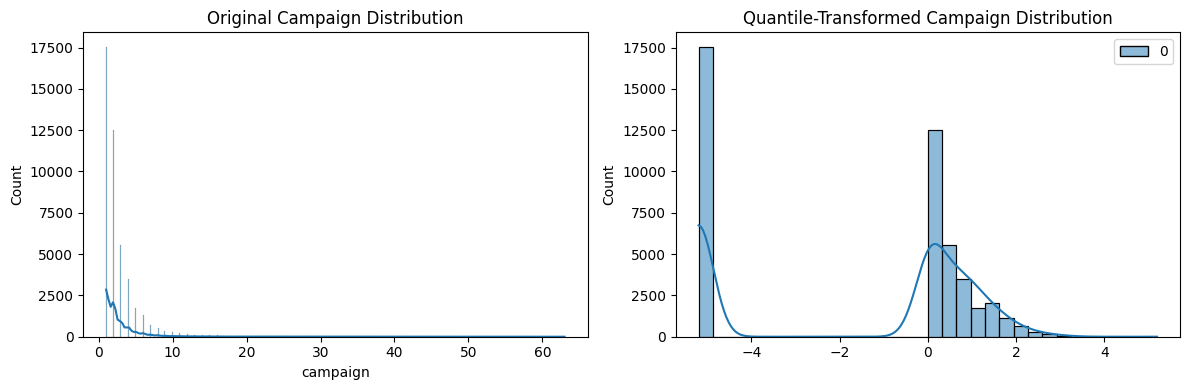

In [82]:
# Visualize 'campaign' distribution (original vs. Quantile-transformed)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: Original Distribution
sns.histplot(df['campaign'], kde=True, ax=axes[0])
axes[0].set_title('Original Campaign Distribution')

# Plot 2: Quantile-Transformed Distribution (Normal)
# QuantileTransformer is used because the data is highly skewed and discrete; 
# it forces the distribution into a Gaussian (Normal) shape, which is often 
# more effective for MLP convergence than a simple log transform.
qt = QuantileTransformer(output_distribution='normal', random_state=42)
campaign_qt = qt.fit_transform(df[['campaign']])
sns.histplot(campaign_qt, kde=True, ax=axes[1])
axes[1].set_title('Quantile-Transformed Campaign Distribution')

plt.tight_layout()
plt.show()

# Insights:
# The Quantile transformation is necessary because Neural Networks (MLP) perform better 
# when feature distributions are roughly symmetric and follow a Normal distribution.

Age mean before scaling (train): 40.9417
Age std before scaling (train): 10.6320


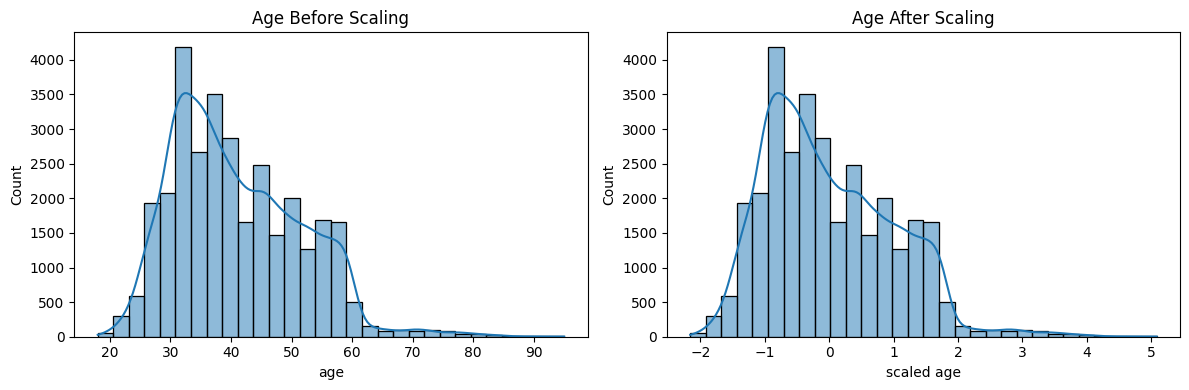

In [83]:
# Data Preprocessing Step 5: Feature Scaling
# Work through numeric columns one at a time. Start with age.

# 1. Age: inspect the training-set distribution before scaling.
train_age_before_scaling = train_df['age'].copy()
print(f"Age mean before scaling (train): {train_age_before_scaling.mean():.4f}")
print(f"Age std before scaling (train): {train_age_before_scaling.std():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train_age_before_scaling, bins=30, kde=True, ax=axes[0])
axes[0].set_title('Age Before Scaling')
axes[0].set_xlabel('age')

# Apply standardization using training-set statistics only.
age_scaler = StandardScaler()
train_df[['age']] = age_scaler.fit_transform(train_df[['age']])
val_df[['age']] = age_scaler.transform(val_df[['age']])
test_df[['age']] = age_scaler.transform(test_df[['age']])

sns.histplot(train_df['age'], bins=30, kde=True, ax=axes[1])
axes[1].set_title('Age After Scaling')
axes[1].set_xlabel('scaled age')

plt.tight_layout()
plt.show()


Balance mean before scaling (train): 1357.9855
Balance std before scaling (train): 2976.8744


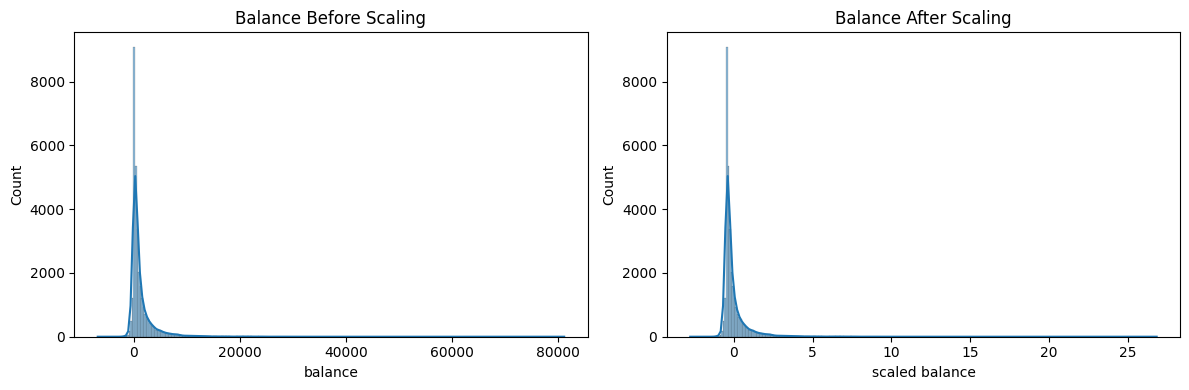

In [84]:
# 2. Balance Standardization
train_balance_before_scaling = train_df['balance'].copy()
print(f"Balance mean before scaling (train): {train_balance_before_scaling.mean():.4f}")
print(f"Balance std before scaling (train): {train_balance_before_scaling.std():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train_balance_before_scaling, bins=300, kde=True, ax=axes[0])
axes[0].set_title('Balance Before Scaling')
axes[0].set_xlabel('balance')

# Apply standardization using training-set statistics only.
balance_scaler = StandardScaler()
train_df[['balance']]= balance_scaler.fit_transform(train_df[['balance']])
val_df[['balance']] = balance_scaler.transform(val_df[['balance']])
test_df[['balance']] = balance_scaler.transform(test_df[['balance']])

sns.histplot(train_df['balance'], bins=300, kde=True, ax=axes[1])
axes[1].set_title('Balance After Scaling')
axes[1].set_xlabel('scaled balance')

plt.tight_layout()
plt.show()


Duration mean before scaling (train): 257.5701
Duration std before scaling (train): 258.8338


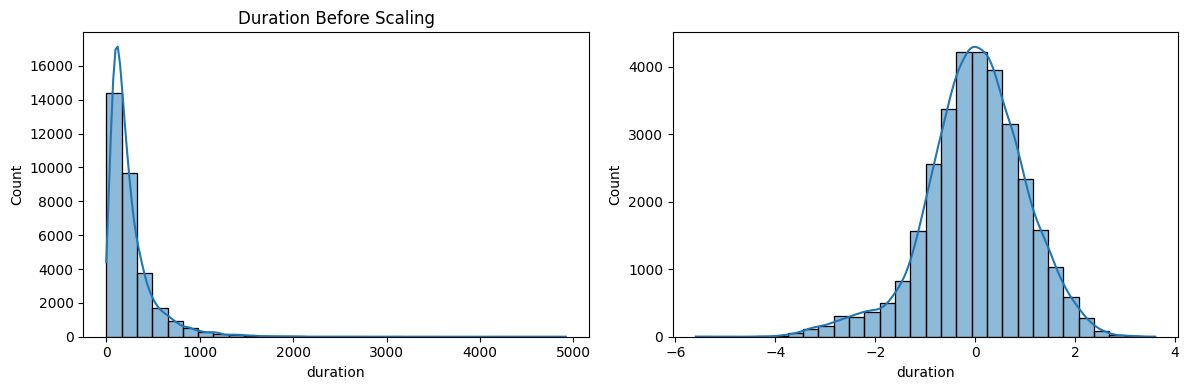

In [85]:
# 3. Duration Standardization
train_duration_before_scaling = train_df['duration'].copy()
print(f"Duration mean before scaling (train): {train_duration_before_scaling.mean():.4f}")
print(f"Duration std before scaling (train): {train_duration_before_scaling.std():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train_duration_before_scaling, bins=30, kde=True, ax=axes[0])
axes[0].set_title('Duration Before Scaling')
axes[0].set_xlabel('duration')

# We notice is skewed so applied log transformation
train_df['duration'] = np.log(train_df['duration'] + 1)
val_df['duration'] = np.log(val_df['duration'] + 1)
test_df['duration'] = np.log(test_df['duration'] + 1)

# Apply standardization using training-set statistics only.
duration_scaler = StandardScaler()
train_df[['duration']] = duration_scaler.fit_transform(train_df[['duration']])
val_df[['duration']] = duration_scaler.transform(val_df[['duration']])
test_df[['duration']] = duration_scaler.transform(test_df[['duration']])

# Check the distribution of the transformed duration
sns.histplot(train_df['duration'], bins=30, kde=True, ax=axes[1])

plt.tight_layout()
plt.show()


Campaign mean before scaling (train): 2.7722
Campaign std before scaling (train): 3.1540


Exception ignored while calling deallocator <function tqdm.__del__ at 0x123145850>:
Traceback (most recent call last):
  File "/Users/charliemei/Desktop/4995HW2/venv/lib/python3.14/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/Users/charliemei/Desktop/4995HW2/venv/lib/python3.14/site-packages/tqdm/notebook.py", line 277, in close
    self.disp(bar_style='danger', check_delay=False)
AttributeError: 'tqdm_notebook' object has no attribute 'disp'


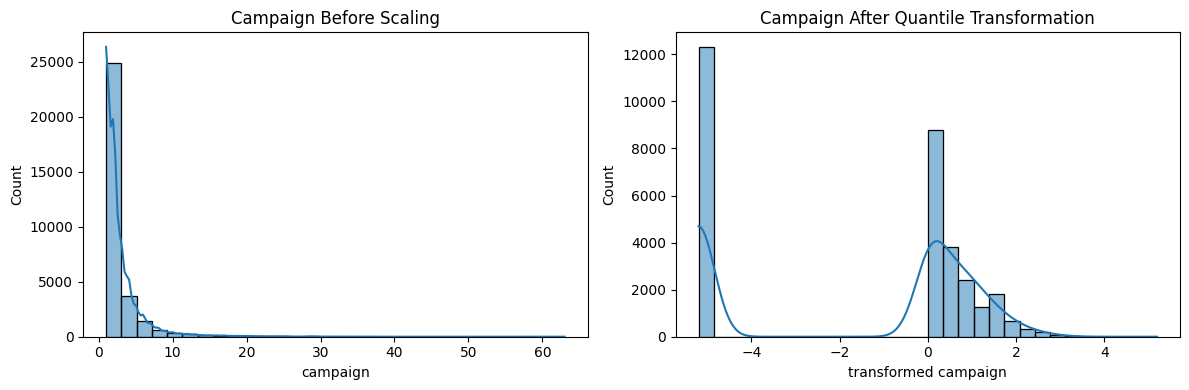

In [86]:
# 4. Campaign Scaling
train_campaign_before_scaling = train_df['campaign'].copy()
print(f"Campaign mean before scaling (train): {train_campaign_before_scaling.mean():.4f}")
print(f"Campaign std before scaling (train): {train_campaign_before_scaling.std():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train_campaign_before_scaling, bins=30, kde=True, ax=axes[0])
axes[0].set_title('Campaign Before Scaling')
axes[0].set_xlabel('campaign')

# QuantileTransformer is used because the data is highly skewed and discrete; 
# it forces the distribution into a Gaussian (Normal) shape, 
# which is often more effective for MLP convergence than a simple log transform.
campaign_transformer = QuantileTransformer(output_distribution='normal', random_state=42)
train_df[['campaign']] = campaign_transformer.fit_transform(train_df[['campaign']])
val_df[['campaign']] = campaign_transformer.transform(val_df[['campaign']])
test_df[['campaign']] = campaign_transformer.transform(test_df[['campaign']])

# Check the distribution of the transformed campaign
sns.histplot(train_df['campaign'], bins=30, kde=True, ax=axes[1])
axes[1].set_title('Campaign After Quantile Transformation')
axes[1].set_xlabel('transformed campaign')

plt.tight_layout()
plt.show()

# Apply standardization using training-set statistics only.
campaign_scaler = StandardScaler()
train_df[['campaign']] = campaign_scaler.fit_transform(train_df[['campaign']])
val_df[['campaign']] = campaign_scaler.transform(val_df[['campaign']])
test_df[['campaign']] = campaign_scaler.transform(test_df[['campaign']])


Previous mean before scaling (train): 0.5859
Previous std before scaling (train): 2.4360


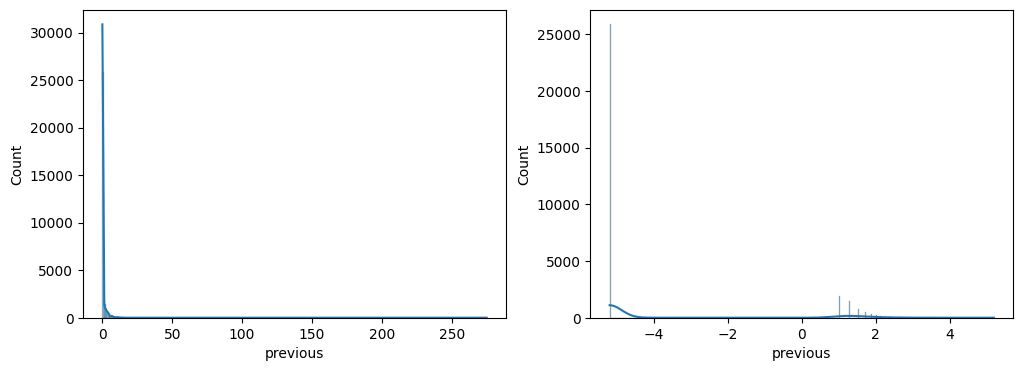

In [87]:
# 5. Previous Standardization
train_previous_before_scaling = train_df['previous'].copy()
print(f"Previous mean before scaling (train): {train_previous_before_scaling.mean():.4f}")
print(f"Previous std before scaling (train): {train_previous_before_scaling.std():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train_previous_before_scaling, bins=300, kde=True, ax=axes[0])

# apply log transformation
previous_transformer = QuantileTransformer(output_distribution='normal', random_state=42)
train_df['previous'] = previous_transformer.fit_transform(train_df[['previous']])
val_df['previous'] = previous_transformer.transform(val_df[['previous']])
test_df['previous'] = previous_transformer.transform(test_df[['previous']])

# check the distribution of the transformed previous
sns.histplot(train_df['previous'], bins=300, kde=True, ax=axes[1])

# Apply standardization using training-set statistics only.
previous_scaler = StandardScaler()
train_df[['previous']] = previous_scaler.fit_transform(train_df[['previous']])
val_df[['previous']] = previous_scaler.transform(val_df[['previous']])
test_df[['previous']] = previous_scaler.transform(test_df[['previous']])

Pdays mean before scaling (train): 40.3433
Pdays std before scaling (train): 100.6782


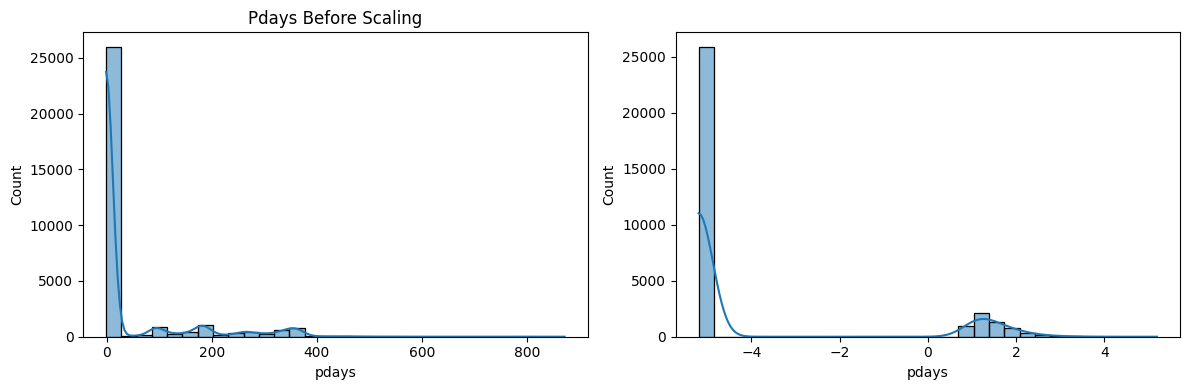

In [88]:
# 6. Pdays Standardization
train_pdays_before_scaling = train_df['pdays'].copy()
print(f"Pdays mean before scaling (train): {train_pdays_before_scaling.mean():.4f}")
print(f"Pdays std before scaling (train): {train_pdays_before_scaling.std():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train_pdays_before_scaling, bins=30, kde=True, ax=axes[0])
axes[0].set_title('Pdays Before Scaling')
axes[0].set_xlabel('pdays')

# apply quantile transformation
pdays_transformer = QuantileTransformer(output_distribution='normal', random_state=42)
train_df[['pdays']] = pdays_transformer.fit_transform(train_df[['pdays']])
val_df[['pdays']] = pdays_transformer.transform(val_df[['pdays']])
test_df[['pdays']] = pdays_transformer.transform(test_df[['pdays']])

# check the distribution of the transformed pdays
sns.histplot(train_df['pdays'], bins=30, kde=True, ax=axes[1])

plt.tight_layout()
plt.show()

# Apply Standardization using training-set statistics only.
pdays_scaler = StandardScaler()
train_df[['pdays']] = pdays_scaler.fit_transform(train_df[['pdays']])
val_df[['pdays']] = pdays_scaler.transform(val_df[['pdays']])
test_df[['pdays']] = pdays_scaler.transform(test_df[['pdays']])

Day of year mean before scaling (train): 171.3938
Day of year std before scaling (train): 74.7509


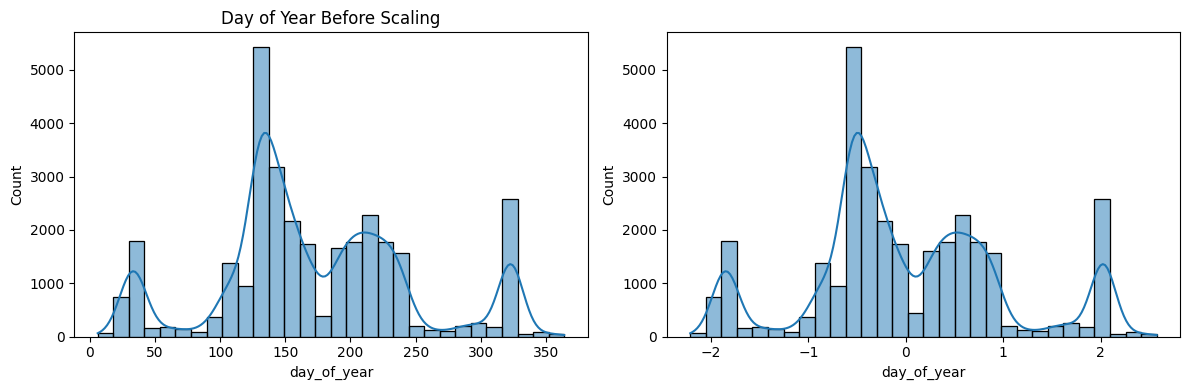

In [89]:
# 7. Day of year standardization
train_day_of_year_before_scaling = train_df['day_of_year'].copy()
print(f"Day of year mean before scaling (train): {train_day_of_year_before_scaling.mean():.4f}")
print(f"Day of year std before scaling (train): {train_day_of_year_before_scaling.std():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train_day_of_year_before_scaling, bins=30, kde=True, ax=axes[0])
axes[0].set_title('Day of Year Before Scaling')
axes[0].set_xlabel('day_of_year')

# Apply standardization using training-set statistics only.
day_of_year_scaler = StandardScaler()
train_df[['day_of_year']] = day_of_year_scaler.fit_transform(train_df[['day_of_year']])
val_df[['day_of_year']] = day_of_year_scaler.transform(val_df[['day_of_year']])
test_df[['day_of_year']] = day_of_year_scaler.transform(test_df[['day_of_year']])

sns.histplot(train_df['day_of_year'], bins=30, kde=True, ax=axes[1])

plt.tight_layout()
plt.show()

In [90]:
#  Store the scaled data in a new csv file for MLP
train_df.to_csv('scaled_train_bank_marketing.csv', index=False)
val_df.to_csv('scaled_val_bank_marketing.csv', index=False)
test_df.to_csv('scaled_test_bank_marketing.csv', index=False)

# print the shape of the scaled data
print(train_df.shape)

(31647, 37)


## 2. Gradient Boosted Tree (GBDT)

In this section, we will train an `XGBClassifier` and explore the effect of different parameters on performance and overfitting. We will use `eval_set` and `early_stopping_rounds` to monitor convergence.

In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from xgboost import plot_importance
from sklearn.metrics import classification_report, accuracy_score

# Load the scaled data
train_df = pd.read_csv('scaled_train_bank_marketing.csv')
val_df = pd.read_csv('scaled_val_bank_marketing.csv')
test_df = pd.read_csv('scaled_test_bank_marketing.csv')

# Define features and target
X_train = train_df.drop(columns=['y'])
y_train = train_df['y']
X_val = val_df.drop(columns=['y'])
y_val = val_df['y']
X_test = test_df.drop(columns=['y'])
y_test = test_df['y']

### Train XGBClassifier with Early Stopping
We initialize the model with a large number of `n_estimators` and use `early_stopping_rounds` to find the optimal point where validation loss stops improving.

In [92]:
# Initialize the classifier
xgb_clf = xgb.XGBClassifier(
    n_estimators=1000, 
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    early_stopping_rounds=50 
)

# Train the model with eval_set
xgb_clf.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False
)

print(f"Best iteration: {xgb_clf.best_iteration}")
y_pred = xgb_clf.predict(X_test)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")

Best iteration: 474
Test Accuracy: 0.9161


### Visualize Training vs. Validation Loss

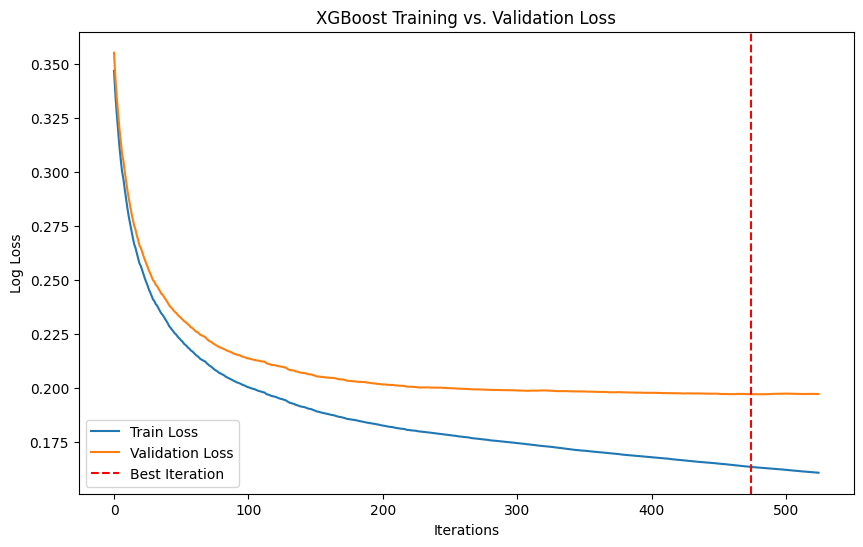

In [93]:
results = xgb_clf.evals_result()
plt.figure(figsize=(10, 6))
plt.plot(results['validation_0']['logloss'], label='Train Loss')
plt.plot(results['validation_1']['logloss'], label='Validation Loss')
plt.axvline(xgb_clf.best_iteration, color='r', linestyle='--', label='Best Iteration')
plt.title('XGBoost Training vs. Validation Loss')
plt.xlabel('Iterations')
plt.ylabel('Log Loss')
plt.legend()
plt.show()

### Feature Importance

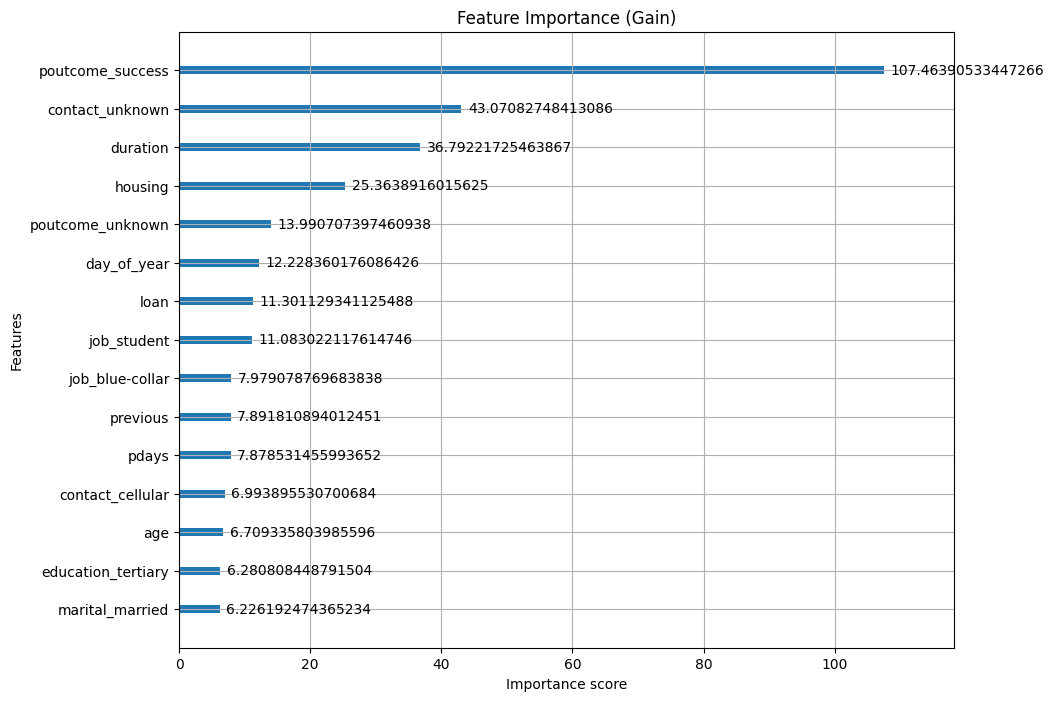

In [94]:
fig, ax = plt.subplots(figsize=(10, 8))
plot_importance(xgb_clf, ax=ax, max_num_features=15, importance_type='gain')
plt.title('Feature Importance (Gain)')
plt.show()

### Effect of Learning Rate
Comparing convergence for `learning_rate` values: 0.01, 0.1, 0.3.

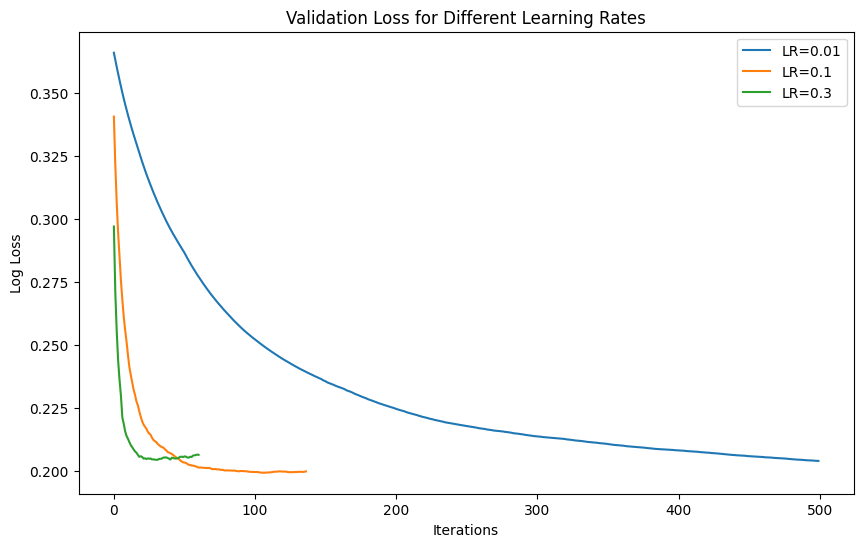

In [95]:
learning_rates = [0.01, 0.1, 0.3]
plt.figure(figsize=(10, 6))

for lr in learning_rates:
    model = xgb.XGBClassifier(
        n_estimators=500,
        learning_rate=lr,
        eval_metric="logloss",
        early_stopping_rounds=30,
        random_state=42
    )
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    plt.plot(model.evals_result()['validation_0']['logloss'], label=f'LR={lr}')

plt.title('Validation Loss for Different Learning Rates')
plt.xlabel('Iterations')
plt.ylabel('Log Loss')
plt.legend()
plt.show()

### Explore Other Parameters
We observe how `max_depth`, `subsample`, `reg_alpha`, and `reg_lambda` affect performance.

In [96]:
from sklearn.metrics import precision_score, recall_score, f1_score

def test_params_comprehensive(param_name, values):
    results_list = []
    for val in values:
        params = {
            'n_estimators': 500,
            'learning_rate': 0.1,
            'max_depth': 4,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'eval_metric': 'logloss',
            'early_stopping_rounds': 30,
            'random_state': 42,
            param_name: val
        }
        
        model = xgb.XGBClassifier(**params)
        # Using validation set for early stopping and metric calculation
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
        
        # Get metrics
        y_pred = model.predict(X_test)
        best_iter = model.best_iteration
        # evals_result() uses validation_0 for the first set in eval_set
        val_loss = model.evals_result()['validation_0']['logloss'][best_iter]
        
        results_list.append({
            'Value': val,
            'Best Iteration': best_iter,
            'Val LogLoss': round(val_loss, 4),
            'Accuracy': round(accuracy_score(y_test, y_pred), 4),
            'Precision (class 1)': round(precision_score(y_test, y_pred), 4),
            'Recall (class 1)': round(recall_score(y_test, y_pred), 4),
            'F1 Score (class 1)': round(f1_score(y_test, y_pred), 4)
        })
    
    df_res = pd.DataFrame(results_list)
    print(f"\n--- Effect of {param_name} ---")
    display(df_res)
    return df_res

# Run experiments for each parameter
depth_results = test_params_comprehensive('max_depth', [3, 6, 10])
subsample_results = test_params_comprehensive('subsample', [0.5, 0.8, 1.0])
alpha_results = test_params_comprehensive('reg_alpha', [0, 0.1, 1.0])
lambda_results = test_params_comprehensive('reg_lambda', [0.1, 1.0, 10.0])


--- Effect of max_depth ---


,Value,Best Iteration,Val LogLoss,Accuracy,Precision (class 1),Recall (class 1),F1 Score (class 1)
0,3,408,0.1986,0.9136,0.6690,0.4865,0.5633
1,6,92,0.1983,0.9137,0.6655,0.4968,0.5689
2,10,67,0.2020,0.9129,0.6592,0.4955,0.5658



--- Effect of subsample ---


,Value,Best Iteration,Val LogLoss,Accuracy,Precision (class 1),Recall (class 1),F1 Score (class 1)
0,0.5,209,0.1999,0.9145,0.6756,0.4878,0.5665
1,0.8,228,0.1982,0.9161,0.6825,0.5006,0.5776
2,1.0,219,0.1982,0.9145,0.6737,0.4916,0.5685



--- Effect of reg_alpha ---


,Value,Best Iteration,Val LogLoss,Accuracy,Precision (class 1),Recall (class 1),F1 Score (class 1)
0,0.0,228,0.1982,0.9161,0.6825,0.5006,0.5776
1,0.1,227,0.1968,0.9136,0.6684,0.4878,0.5640
2,1.0,227,0.1975,0.9146,0.6719,0.4981,0.5721



--- Effect of reg_lambda ---


,Value,Best Iteration,Val LogLoss,Accuracy,Precision (class 1),Recall (class 1),F1 Score (class 1)
0,0.1,219,0.1986,0.9160,0.6788,0.5058,0.5796
1,1.0,228,0.1982,0.9161,0.6825,0.5006,0.5776
2,10.0,225,0.1984,0.9146,0.6737,0.4942,0.5702


### Train MLPClassifier using scikit-learn
We train an `MLPClassifier` and explore the impact of `hidden_layer_sizes`, `activation`, `learning_rate_init`, and `max_iter` on performance. Note that the data has already been standardized.

/Users/charliemei/Desktop/4995HW2/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Exploring hidden_layer_sizes...


Layers: (256, 128, 64): 100%|██████████| 100/100 [00:24<00:00,  4.10it/s, loss=0.0785]


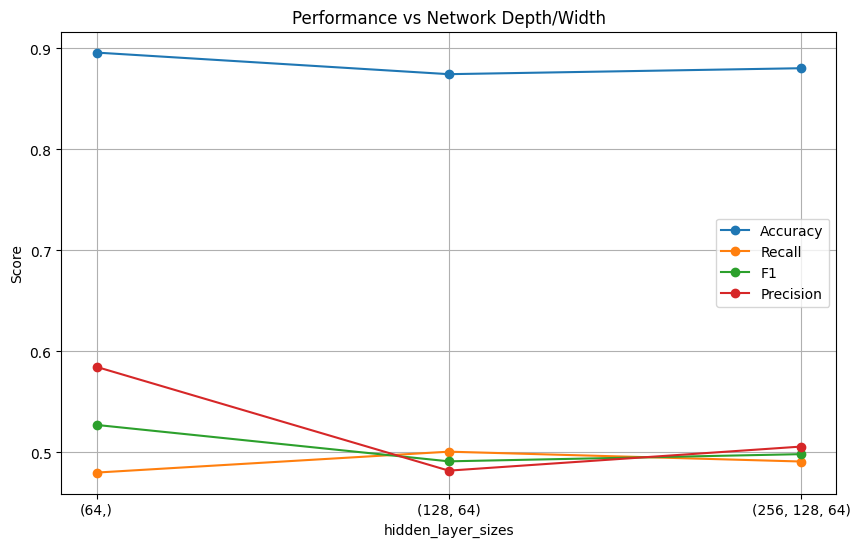


Exploring activation functions...


Activation: tanh: 100%|██████████| 100/100 [00:14<00:00,  6.78it/s, loss=0.0674]


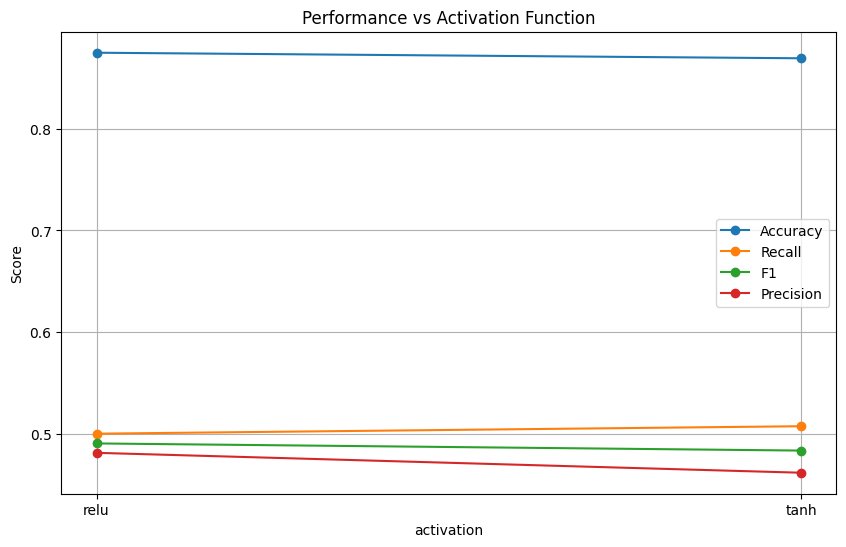


Exploring learning_rate_init...


LR: 0.1: 100%|██████████| 150/150 [00:16<00:00,  9.15it/s, loss=0.2207]


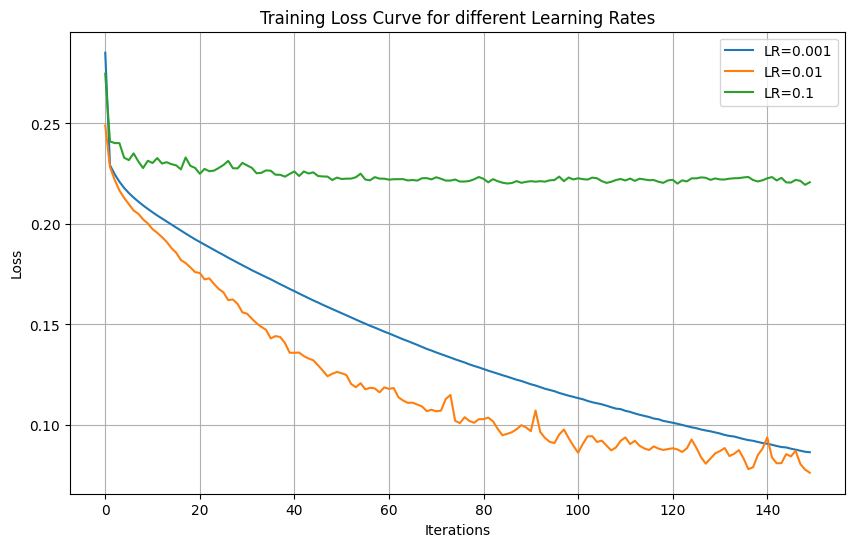

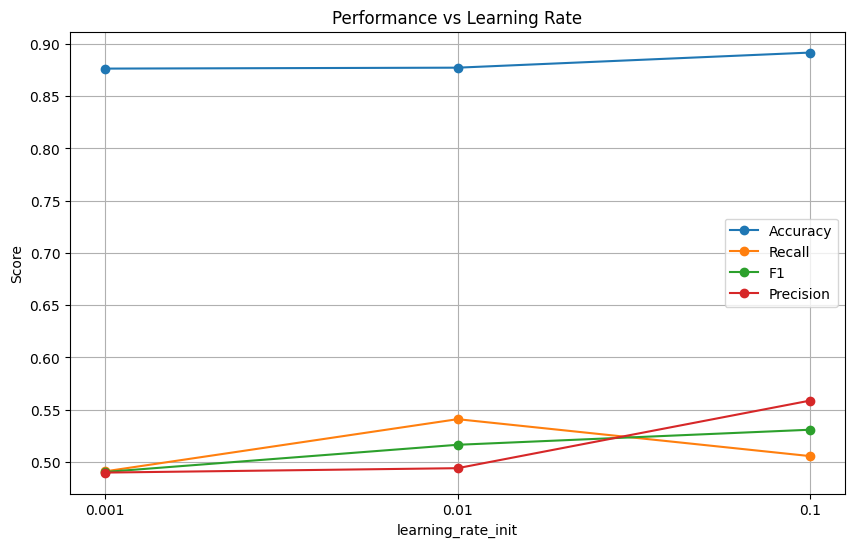

Note: sklearn.neural_network.MLPClassifier is CPU-only. CUDA is not supported for this specific model.


In [100]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import time

# Set random seed for reproducibility
RANDOM_SEED = 42

# Function to train MLP with progress bar and return metrics
def train_and_evaluate_mlp(params, X_train, y_train, X_val, y_val, desc="Training"):
    # We use warm_start and partial_fit to implement the progress bar
    # since standard fit() doesn't expose iterations to tqdm easily.
    max_iter = params.get('max_iter', 200)
    mlp_params = params.copy()
    mlp_params['max_iter'] = 1  # We'll step manually
    mlp_params['warm_start'] = True
    mlp_params['random_state'] = RANDOM_SEED
    
    mlp = MLPClassifier(**mlp_params)
    classes = np.unique(y_train)
    
    loss_curve = []
    
    # tqdm to monitor speed and progress
    pbar = tqdm(range(max_iter), desc=desc)
    for i in pbar:
        mlp.partial_fit(X_train, y_train, classes=classes)
        loss_curve.append(mlp.loss_)
        pbar.set_postfix({'loss': f"{mlp.loss_:.4f}"})
        
    y_pred_val = mlp.predict(X_val)
    
    metrics = {
        'accuracy': accuracy_score(y_val, y_pred_val),
        'recall': recall_score(y_val, y_pred_val),
        'f1': f1_score(y_val, y_pred_val),
        'precision': precision_score(y_val, y_pred_val),
        'loss_curve': loss_curve
    }
    
    return metrics

# Function to plot performance metrics
def plot_experiment_results(results_df, param_name, title):
    plt.figure(figsize=(10, 6))
    metrics = ['accuracy', 'recall', 'f1', 'precision']
    
    for metric in metrics:
        plt.plot(results_df[param_name].astype(str), results_df[metric], marker='o', label=metric.capitalize())
    
    plt.title(title)
    plt.xlabel(param_name)
    plt.ylabel("Score")
    plt.legend()
    plt.grid(True)
    plt.show()

# 1. Explore hidden_layer_sizes (Effect of network depth/width)
print("Exploring hidden_layer_sizes...")
hidden_configs = [(64,), (128, 64), (256, 128, 64)]
hidden_results = []

for config in hidden_configs:
    res = train_and_evaluate_mlp(
        {'hidden_layer_sizes': config, 'max_iter': 100, 'learning_rate_init': 0.01},
        X_train, y_train, X_val, y_val,
        desc=f"Layers: {config}"
    )
    res['hidden_layer_sizes'] = config
    hidden_results.append(res)

df_hidden = pd.DataFrame(hidden_results)
plot_experiment_results(df_hidden, 'hidden_layer_sizes', "Performance vs Network Depth/Width")

# 2. Explore activation (relu vs tanh)
print("\nExploring activation functions...")
activations = ['relu', 'tanh']
activation_results = []

for act in activations:
    res = train_and_evaluate_mlp(
        {'activation': act, 'max_iter': 100, 'hidden_layer_sizes': (128, 64), 'learning_rate_init': 0.01},
        X_train, y_train, X_val, y_val,
        desc=f"Activation: {act}"
    )
    res['activation'] = act
    activation_results.append(res)

df_activation = pd.DataFrame(activation_results)
plot_experiment_results(df_activation, 'activation', "Performance vs Activation Function")

# 3. Explore learning_rate_init (and visualize loss curves)
print("\nExploring learning_rate_init...")
learning_rates = [0.001, 0.01, 0.1]
lr_results = []

plt.figure(figsize=(10, 6))
for lr in learning_rates:
    res = train_and_evaluate_mlp(
        {'learning_rate_init': lr, 'max_iter': 150, 'hidden_layer_sizes': (128, 64)},
        X_train, y_train, X_val, y_val,
        desc=f"LR: {lr}"
    )
    res['learning_rate_init'] = lr
    lr_results.append(res)
    plt.plot(res['loss_curve'], label=f"LR={lr}")

plt.title("Training Loss Curve for different Learning Rates")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

df_lr = pd.DataFrame(lr_results)
plot_experiment_results(df_lr, 'learning_rate_init', "Performance vs Learning Rate")

# Note on CUDA:
# sklearn's MLPClassifier does not support GPU/CUDA directly as it's built on NumPy/SciPy.
# To use CUDA, a transition to PyTorch or a similar framework would be required.
print("Note: sklearn.neural_network.MLPClassifier is CPU-only. CUDA is not supported for this specific model.")
